<a href="https://colab.research.google.com/github/akash-gupta06/EV-BatteryLife-Prediction-ANN/blob/main/EV_BatterLife_Prediction_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Importing Libraries**


In [1]:
import pandas as pd

# keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,LabelEncoder

In [3]:
df = pd.read_csv("/content/NASA-battery-data.csv")
df.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


Data Preprocessing

In [4]:
# Droping the irrelevent columns


In [5]:
df.columns

Index(['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id',
       'uid', 'filename', 'Capacity', 'Re', 'Rct'],
      dtype='object')

In [7]:
df = df.drop(['start_time','battery_id', 'test_id',
       'uid', 'filename'], axis=1)

In [8]:
df

,type,ambient_temperature,Capacity,Re,Rct
0,discharge,4,1.6743047446975208,NaN,NaN
1,impedance,24,NaN,0.05605783343888099,0.20097016584458333
2,charge,4,NaN,NaN,NaN
3,impedance,24,NaN,0.05319185850921101,0.16473399914864734
4,discharge,4,1.5243662105099023,NaN,NaN
...,...,...,...,...,...
7560,impedance,24,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,4,1.0201379996149256,NaN,NaN
7562,charge,4,NaN,NaN,NaN
7563,discharge,4,0.9907591663373165,NaN,NaN


In [9]:
df.isnull().sum()

,0
type,0
ambient_temperature,0
Capacity,4771
Re,5609
Rct,5609


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   type                 7565 non-null   object
 1   ambient_temperature  7565 non-null   int64 
 2   Capacity             2794 non-null   object
 3   Re                   1956 non-null   object
 4   Rct                  1956 non-null   object
dtypes: int64(1), object(4)
memory usage: 295.6+ KB


In [11]:
# converting string to numeric data type

In [12]:
df['Capacity']=pd.to_numeric(df['Capacity'], errors='coerce')
df['Rct']=pd.to_numeric(df['Rct'], errors='coerce')
df['Re']=pd.to_numeric(df['Re'], errors='coerce')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 7565 non-null   object 
 1   ambient_temperature  7565 non-null   int64  
 2   Capacity             2769 non-null   float64
 3   Re                   1947 non-null   float64
 4   Rct                  1947 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 295.6+ KB


In [14]:
# fiiling the missing value

In [15]:
df.isnull().sum()

,0
type,0
ambient_temperature,0
Capacity,4796
Re,5618
Rct,5618


In [17]:
df['Capacity'].fillna(df['Capacity'].mean(), inplace=True)
df['Re'].fillna(df['Re'].mean(), inplace=True)
df['Rct'].fillna(df['Rct'].mean(), inplace=True)

/tmp/ipykernel_4359/3146253482.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Capacity'].fillna(df['Capacity'].mean(), inplace=True)
/tmp/ipykernel_4359/3146253482.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [19]:
df.isnull().sum()

,0
type,0
ambient_temperature,0
Capacity,0
Re,0
Rct,0


**Encoding**

In [20]:
df.columns

Index(['type', 'ambient_temperature', 'Capacity', 'Re', 'Rct'], dtype='object')

In [21]:
df['type'].value_counts()

,count
type,
charge,2815
discharge,2794
impedance,1956


In [22]:
label_encoder = LabelEncoder()
df['type']= label_encoder.fit_transform(df['type'])

In [23]:
df.head()

,type,ambient_temperature,Capacity,Re,Rct
0,1,4,1.674305,-4.976500e+11,1.055903e+12
1,2,24,1.326543,5.605783e-02,2.009702e-01
2,0,4,1.326543,-4.976500e+11,1.055903e+12
3,2,24,1.326543,5.319186e-02,1.647340e-01
4,1,4,1.524366,-4.976500e+11,1.055903e+12


In [24]:
df['type'].unique()

array([1, 2, 0])

**Train test Split**

In [25]:
X = df.drop(columns='ambient_temperature')

In [26]:
X

,type,Capacity,Re,Rct
0,1,1.674305,-4.976500e+11,1.055903e+12
1,2,1.326543,5.605783e-02,2.009702e-01
2,0,1.326543,-4.976500e+11,1.055903e+12
3,2,1.326543,5.319186e-02,1.647340e-01
4,1,1.524366,-4.976500e+11,1.055903e+12
...,...,...,...,...
7560,2,1.326543,9.680880e-02,1.548974e-01
7561,1,1.020138,-4.976500e+11,1.055903e+12
7562,0,1.326543,-4.976500e+11,1.055903e+12
7563,1,0.990759,-4.976500e+11,1.055903e+12


In [27]:
y = df['ambient_temperature']

In [28]:
y

,ambient_temperature
0,4
1,24
2,4
3,24
4,4
...,...
7560,24
7561,4
7562,4
7563,4


In [29]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [30]:
X_train.shape

(6052, 4)

In [31]:
X_test.shape

(1513, 4)

**Scaling**

In [32]:
X_train

,type,Capacity,Re,Rct
4552,2,1.326543,6.085987e-02,7.840240e-02
4450,1,1.203903,-4.976500e+11,1.055903e+12
1656,1,0.095185,-4.976500e+11,1.055903e+12
3570,0,1.326543,-4.976500e+11,1.055903e+12
6618,1,1.414787,-4.976500e+11,1.055903e+12
...,...,...,...,...
5191,0,1.326543,-4.976500e+11,1.055903e+12
5226,2,1.326543,4.691623e-02,6.913344e-02
5390,2,1.326543,5.415675e-02,7.505844e-02
860,2,1.326543,6.928730e-02,1.985768e-01


In [33]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [34]:
X_train_scaled

array([[1.00000000e+00, 5.02450122e-01, 9.99999999e-01, 1.98111482e-10],
       [5.00000000e-01, 4.55998175e-01, 0.00000000e+00, 1.00000000e+00],
       [5.00000000e-01, 3.60527766e-02, 0.00000000e+00, 1.00000000e+00],
       ...,
       [1.00000000e+00, 5.02450122e-01, 9.99999999e-01, 1.98108315e-10],
       [1.00000000e+00, 5.02450122e-01, 9.99999999e-01, 1.98225294e-10],
       [0.00000000e+00, 5.02450122e-01, 0.00000000e+00, 1.00000000e+00]])

**MODEL BUILDING**

In [39]:
model = Sequential()

#Input Layer and first Hidden layer
model.add(Dense(units=64, activation='relu', input_dim=X_train_scaled.shape[1]))

#adding dropout layer
model.add(Dropout(0.2))

#second hidden layer
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))

#output layer
model.add(Dense(units=1, activation='linear'))

#compile
model.compile(optimizer='adam', loss='mean_squared_error')

#model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

**Training our Model**

In [40]:
history = model.fit(X_train_scaled, y_train, epochs=200, batch_size=32, validation_data=(X_test_scaled,y_test))

Epoch 1/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 267.9791 - val_loss: 111.7255
Epoch 2/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 117.5234 - val_loss: 116.0315
Epoch 3/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 113.9850 - val_loss: 115.9310
Epoch 4/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 113.6576 - val_loss: 124.1617
Epoch 5/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 109.6776 - val_loss: 136.4317
Epoch 6/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 107.7004 - val_loss: 128.8528
Epoch 7/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 105.7965 - val_loss: 144.9716
Epoch 8/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 105.2400 - val_loss: 144.2767
Epoch 9/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 103.4687 - val_loss: 169.1726
Epoch 10/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 102.5377 - val_loss: 170.6916
Epoch 11/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 100.6309 - val_loss: 179.44

**Model Evaluation**

In [43]:
import matplotlib.pyplot as plt

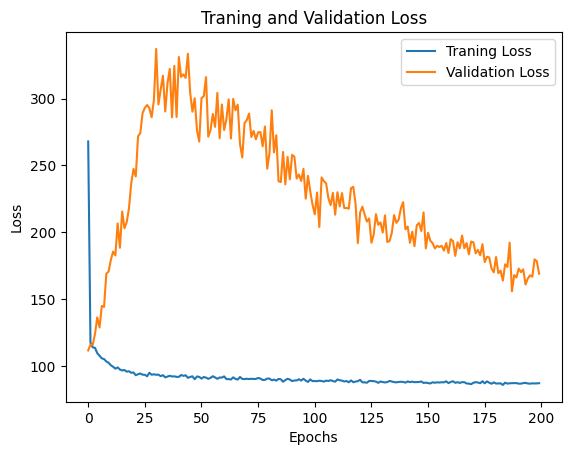

In [45]:
plt.plot(history.history['loss'], label='Traning Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Traning and Validation Loss")
plt.show()

In [46]:
model.evaluate(X_test_scaled, y_test)

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 169.0652


169.065185546875

**Predicting System**

In [47]:
import numpy as np

def predict_battery_life(type_discharge, Capacity, Re, Rct, label_encoder, scaler, model):
  #Encode the Categorical feature
  type_discharge_encoded = label_encoder.transform([type_discharge])[0]

  #prepare the input feature vector
  X_input = np.array([[type_discharge_encoded,Capacity,Re,Rct]])

  #sacle the input feature using same scaler
  X_input_scaled = scaler.transform(X_input)

  #Predict the battery life (ambient temperature)
  predicted_battery_life = model.predict(X_input_scaled)

  return predicted_battery_life[0]

In [54]:
#user data
type_discharge= 'charge'
Capacity= 1.674305
Re= -2.976500e+11
Rct= 1.055903e+12


In [55]:
predicted_battery_life = predict_battery_life(type_discharge, Capacity, Re, Rct, label_encoder, scaler, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [56]:
predicted_battery_life

array([34.373825], dtype=float32)

**Saving the files**

In [58]:
import pickle

with open('batter_life_model.pkl','wb') as model_file:
  pickle.dump(model, model_file)
with open('scaler.pkl','wb') as scaler_file:
  pickle.dump(scaler, scaler_file)
with open('label_encoder.pkl','wb') as le_file:
  pickle.dump(label_encoder, le_file)

In [59]:
model.save("battery_life_model.h5")